# Proyecto: Simulaciones de Fisica Económica (Modelo Yard-Sale)
## Metodos Numericos — Grado iMAT — Curso 2025-2026

En este proyecto vamos a estudiar el **modelo yard-sale**, un modelo sencillo
de intercambio de riqueza entre agentes que nos permite explorar una pregunta
fascinante: ¿puede surgir la desigualdad extrema en una sociedad donde todos
los individuos son exactamente iguales y juegan con las mismás reglas?

La idea es simple: partimos de un grupo de personas que empiezan con la misma
riqueza. En cada paso, dos de ellas se eligen al azar y se juegan una cantidad
proporciónal a lo que tiene la más pobre. El ganador se decide tirando una moneda.
Nada más. No hay trampas, no hay ventajas, no hay habilidades distintas.

Y sin embargo, como veremos, el resultado es sorprendente: la riqueza acaba
concentrandose casi por completo en un solo agente. A lo largo de este notebook
implementaremos el modelo, estudiaremos su comportamiento y exploraremos
variantes que intentan corregir o modificar este fenómeno.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Función auxiliar: coeficiente de Gini

Antes de empezar con la simulación, necesitamos una herramienta para medir
cuánta desigualdad hay en nuestro sistema en cada momento. Para eso usamos
el **coeficiente de Gini**, que es una medida clásica en economía:

- Un Gini de **0** significa igualdad perfecta (todos tienen lo mismo).
- Un Gini cercano a **1** significa desigualdad total (uno lo tiene todo).

La fórmula se basa en ordenar las riquezas de menor a mayor y calcular una suma
ponderada. Es una forma compacta de resumir en un solo número como de desigual
es la distribución.

In [2]:
def gini(w):
    """Calcula el coeficiente de Gini de un vector de riquezas."""
    w_sorted = np.sort(w)
    N = len(w)
    indices = np.arange(1, N + 1) # creamos los indices 1, 2, 3, ......, N
    return (2 * np.sum(indices * w_sorted)) / (N * np.sum(w)) - (N + 1) / N

---
## Ejercicio 1: Implementación del modelo yard-sale básico

Aquí implementamos el modelo yard-sale y
ejecutamos la simulación principal que nos dara los datos para los ejercicios
siguientes (del 1 al 8).

**¿Qué hace el modelo?** Tenemos N = 100 agentes que empiezan todos con riqueza 1.
En cada transacción:

1. Se eligen dos agentes al azar.
2. Se calcula cuánto se van a jugar: una fracción epsilon = 0.1 de la riqueza
   del más pobre de los dos.
3. Se tira una moneda (50/50) para decidir quien gana.
4. El ganador suma esa cantidad y el perdedor la resta.

La riqueza total del sistema se conserva siempre (lo que gana uno lo pierde el otro).

**¿Qué registramos?** Además de ejecutar las transacciones, cada N pasos (lo que
llamamos una "ronda") guardamos varias métricas: la riqueza máxima, la fracción
del más rico, el Gini, y la riqueza de 5 agentes concretos que seguimos
individualmente. También guardamos "snapshots" completos del vector de riquezas
en momentos concretos, para poder dibujar los histogramás del ejercicio 3.

La simulación dura 200.000 transacciones, es decir, 2.000 rondas.

In [ ]:
# Ejercicio 1: parametros del modelo y simulacion base
N = 100
epsilon = 0.1
n_trans = 200000
registrar_cada = N   # registrar metricas cada N transacciones (1 ronda)

# Ejercicio 1: riqueza inicial (todos los agentes empiezan con 1)
w = np.ones(N)
W_total = np.sum(w)

# Ejercicios 7 y 8: agentes que vamos a seguir individualmente 
agentes_seg = [0, 10, 25, 50, 75] # indices de los ajentes que vamos a seguir. 
n_seg = len(agentes_seg)

# Ejercicio 3: instantes en los que guardamos snapshots del vector completo de riquezas
snapshots_en = [1000, 10000, 50000, 100000, 200000]

# Ejercicios 4, 5, 6, 7 y 8: preparar los arrays para guardar metricas
n_reg = n_trans // registrar_cada # calculamos cuántas veces vas a registrar datos durante la simulación.
tiempos = np.zeros(n_reg) # en qué instante se guardó cada dato 
hist_max = np.zeros(n_reg) # riqueza del agente más rico en cada registro (ej. 4)
hist_frac = np.zeros(n_reg) # fracción de riqueza del más rico (ej. 5)
hist_gini_arr = np.zeros(n_reg) # evolución del Gini (ej. 6)
hist_agentes = np.zeros((n_seg, n_reg)) # riqueza de algunos agentes concretos (ej. 7)
hist_wins = np.zeros((n_seg, n_reg)) # victorias acumuladas de esos agentes (ej. 8)
hist_losses = np.zeros((n_seg, n_reg)) # derrotas acumuladas de esos agentes (ej. 8 )
wins = np.zeros(n_seg)
derrotas = np.zeros(n_seg)

# Ejercicio 3: guardar snapshot inicial (t = 0)
snapshots = [w.copy()]

# Ejercicio 1: bucle principal de la simulacion
reg = 0
for t in range(1, n_trans + 1):
    
    # Ejercicio 1: elegir los dos agentes al azar y la cantidad intercambiada 
    i, j = np.random.choice(N, size=2, replace=False)
    dw = epsilon * min(w[i], w[j])

    # Ejercicio 1: decidir ganador y actualizar riquezas 
    if np.random.random() < 0.5:
        w[i] = w[i] + dw
        w[j] = w[j] - dw
        ganador = i
        perdedor = j
    else:
        w[i] = w[i] - dw
        w[j] = w[j] + dw
        ganador = j
        perdedor = i

     # Ejercicio 8: registrar victorias y derrotas de los agentes seguidos individualmente 
    for s in range(n_seg):
        # En este bucle no estamos mirando a todos los ajentes, sino que solo 
        # a los que hemos guardado en la lista de agentes_seg. 
        if agentes_seg[s] == ganador:
            wins[s] += 1
        elif agentes_seg[s] == perdedor:
            derrotas[s] += 1

    # Ejercicios 4, 5, 6, 7 y 8: guardar metricas durante la simulacion cada N transacciones 
    if t % registrar_cada == 0:
        tiempos[reg] = t
        hist_max[reg] = np.max(w) # quién es el más rico en ese momento
        hist_frac[reg] = np.max(w) / W_total # qué porcentaje de toda la riqueza tiene
        hist_gini_arr[reg] = gini(w) # cuánta desigualdad hay
        for s in range(n_seg):
            # guardamos riqueza, victorias y derrotas de los 5 agentes seguidos.
            hist_agentes[s, reg] = w[agentes_seg[s]]
            hist_wins[s, reg] = wins[s]
            hist_losses[s, reg] = derrotas[s]
        reg = reg + 1

    # Ejercicio 3: guardar snapshots para hacer los histogramas
    if t in snapshots_en:
        snapshots.append(w.copy())

# Resumen final de los valores que vamos a usar en ejercicios posteriores     
print('------------------------')
print('Simulacion completada')
print('------------------------')
print('Riqueza total conservada:', round(np.sum(w), 6), '(inicial:', W_total, ')')
print('Gini final:', round(gini(w), 4))
print('Riqueza maxima:', round(np.max(w), 4))
print('Riqueza minima:', round(np.min(w), 6))
print()
print('--- Valores adicionales para el analisis ---')
print('Fraccion de riqueza del mas rico: %.4f (%.2f%%)' % (np.max(w)/W_total, 100*np.max(w)/W_total))
print('Agente mas rico (indice): %d' % np.argmax(w))
print()

# Ejercicio 6: Gini en momentos concretos
print('Gini en momentos clave:')
# Lo que hacemos aqui es calcular el valor de Gini para unos tiempos concretos. 
# Primero convertimos el tiempo real t_key en la posición correspondiente dentro del array hist_gini_arr
# Esto lo hacemos porque hist_gini_arr no guarda un valor en cada transacción, sino solo cada registrar_cada transacciones.
# Por ejemplo, si registrar_cada = 100, entonces (5000 // 100) - 1 = 49
# Es decir, que hist_gini_arr[49] es el Gini en t = 5000. 

for t_key in [5000, 10000, 25000, 50000, 100000, 150000]:
    idx_k = t_key // registrar_cada - 1
    print('  t = %6d: Gini = %.4f' % (t_key, hist_gini_arr[idx_k]))
print()

# Ejercicios 4 y 5: riqueza maxima y fraccion del mas rico
print('Riqueza maxima y fraccion en momentos clave:')
# Aqui hacemos lo mismo para calcular los indices. 
# Entonces si por ejemplo en t = 500000 el más rico tiene 12.19 y la riqueza total es 100, entonces:
# w_max = 12.19 y fraccion = 0.1219 --> el más rico tiene el 12.19% del total.

for t_key in [25000, 50000, 100000, 150000]:
    idx_k = t_key // registrar_cada - 1
    print('  t = %6d: w_max = %.4f, fraccion = %.4f' % (t_key, hist_max[idx_k], hist_frac[idx_k]))
print()

# Ejercicio 3: resumen de los snapshots
print('Mediana de la riqueza en cada snapshot:')
for idx_s, t_snap in enumerate([0] + snapshots_en):
    # idx_s = pos en la lista 
    # t_snap = el tiempo real (incluyendo el t = 0)
    snap_s = snapshots[idx_s]
    print('  t = %6d: mediana = %.4f, media = %.4f' % (t_snap, np.median(snap_s), np.mean(snap_s)))
print()

# Ejercicio 7: resumen de la evolucion de los agentes seguidos
print('Picos de riqueza de los agentes seguidos:')
for s in range(n_seg):
    traj = hist_agentes[s, :] # cogemos la trayectoria completa de riqueza del agente s
    peak_val = np.max(traj) # Con esto lo que hacemos es coger la mayor riqueza que alcanzó ese agente en toda la simulación
    peak_idx = int(np.argmax(traj)) # Ahora cogemos la posicion donde sucedio ese maximo 
    peak_t = int(tiempos[peak_idx]) # Y convertimos índice en el tiempo real de la simulación.
    print('  Agente %2d: pico = %.4f en t = %d, riqueza final = %.6f' % (agentes_seg[s], peak_val, peak_t, traj[-1]))


------------------------
Simulacion completada
------------------------
Riqueza total conservada: 100.0 (inicial: 100.0 )
Gini final: 0.9453
Riqueza maxima: 31.7418
Riqueza minima: 0.0

--- Valores adicionales para el analisis ---
Fraccion de riqueza del mas rico: 0.3174 (31.74%)
Agente mas rico (indice): 76

Gini en momentos clave:
  t =   5000: Gini = 0.3991
  t =  10000: Gini = 0.5200
  t =  25000: Gini = 0.6804
  t =  50000: Gini = 0.7967
  t = 100000: Gini = 0.8830
  t = 150000: Gini = 0.9208

Riqueza maxima y fraccion en momentos clave:
  t =  25000: w_max = 7.4007, fraccion = 0.0740
  t =  50000: w_max = 12.1919, fraccion = 0.1219
  t = 100000: w_max = 14.0018, fraccion = 0.1400
  t = 150000: w_max = 23.0036, fraccion = 0.2300

Mediana de la riqueza en cada snapshot:
  t =      0: mediana = 1.0000, media = 1.0000
  t =   1000: mediana = 0.9844, media = 1.0000
  t =  10000: mediana = 0.6952, media = 1.0000
  t =  50000: mediana = 0.0978, media = 1.0000
  t = 100000: mediana = 0.0

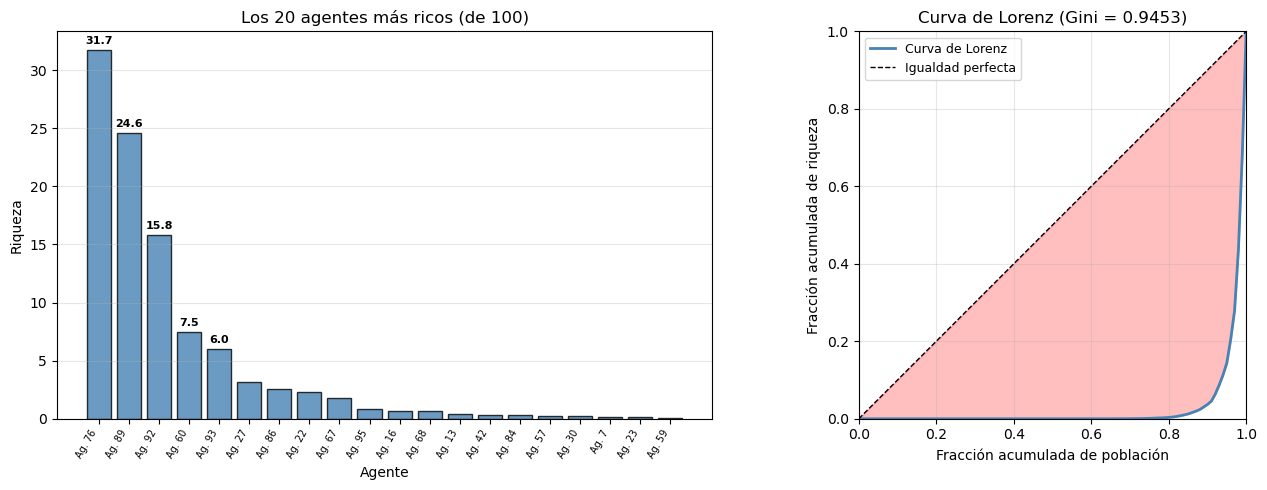

Top 5 agentes por riqueza:
  Rank 1: Agente 76, riqueza = 31.7418 (31.74% del total)
  Rank 2: Agente 89, riqueza = 24.5654 (24.57% del total)
  Rank 3: Agente 92, riqueza = 15.7905 (15.79% del total)
  Rank 4: Agente 60, riqueza = 7.4565 (7.46% del total)
  Rank 5: Agente 93, riqueza = 6.0432 (6.04% del total)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: top 20 agentes con su número real
w_indices = np.argsort(w)[::-1]  # indices ordenados de más rico a más pobre
top = 20
top_riquezas = [w[w_indices[r]] for r in range(top)]
top_labels = ['Ag. %d' % w_indices[r] for r in range(top)]

bars = axes[0].bar(range(top), top_riquezas, color='steelblue', edgecolor='black', alpha=0.8)
for r in range(min(5, top)):
    axes[0].text(r, top_riquezas[r] + 0.5, '%.1f' % top_riquezas[r], ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(range(top))
axes[0].set_xticklabels(top_labels, rotation=60, fontsize=7, ha='right')
axes[0].set_xlabel('Agente')
axes[0].set_ylabel('Riqueza')
axes[0].set_title('Los 20 agentes más ricos (de %d)' % N)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel derecho: Curva de Lorenz
w_lorenz = np.sort(w)
cum_w = np.cumsum(w_lorenz) / np.sum(w_lorenz)
cum_pop = np.arange(1, N + 1) / N
cum_w = np.insert(cum_w, 0, 0)
cum_pop = np.insert(cum_pop, 0, 0)
axes[1].fill_between(cum_pop, cum_pop, cum_w, alpha=0.25, color='red')
axes[1].plot(cum_pop, cum_w, 'steelblue', linewidth=2, label='Curva de Lorenz')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Igualdad perfecta')
axes[1].set_xlabel('Fracción acumulada de población')
axes[1].set_ylabel('Fracción acumulada de riqueza')
axes[1].set_title('Curva de Lorenz (Gini = %.4f)' % gini(w))
axes[1].legend(fontsize=9, loc='upper left')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# Imprimir valores del top 5
print('Top 5 agentes por riqueza:')
for rank in range(5):
    idx = w_indices[rank]
    print('  Rank %d: Agente %d, riqueza = %.4f (%.2f%% del total)' % (rank+1, idx, w[idx], 100*w[idx]/np.sum(w)))

### Animación: flujo de riqueza a lo largo de la simulación

Para visualizar de forma dinámica cómo la riqueza fluye entre los agentes,
generamos una animación que muestra la distribución de riqueza (barras ordenadas
de mayor a menor) en distintos instantes de la simulación. Se observa cómo la
distribución pasa de ser uniforme (todos con riqueza 1) a concentrarse en muy
pocos agentes. El Gini se muestra en tiempo real en el título.

Simulación completada: 151 frames guardados


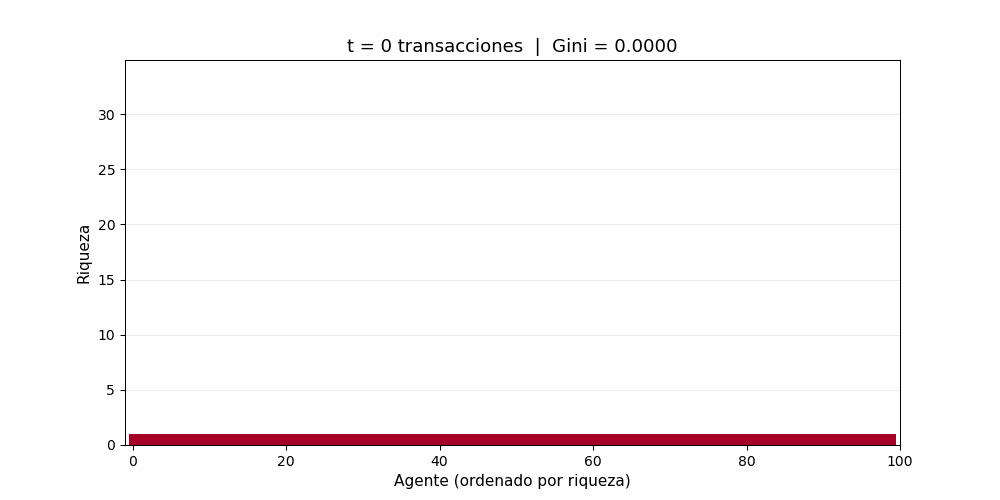

GIF guardado en: animacion_yard_sale.gif


In [5]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# Re-ejecutar la simulación guardando snapshots frecuentes para la animación
np.random.seed(42)
w_anim = np.ones(N)
n_frames = 150  # número de frames del GIF
frames_cada = n_trans // n_frames  # guardar un frame cada X transacciones
snapshots_anim = [w_anim.copy()]
gini_anim = [gini(w_anim)]
tiempos_anim = [0]

for t in range(1, n_trans + 1):
    i_ag, j_ag = np.random.choice(N, size=2, replace=False)
    dw = epsilon * min(w_anim[i_ag], w_anim[j_ag])
    if np.random.random() < 0.5:
        w_anim[i_ag] = w_anim[i_ag] + dw
        w_anim[j_ag] = w_anim[j_ag] - dw
    else:
        w_anim[i_ag] = w_anim[i_ag] - dw
        w_anim[j_ag] = w_anim[j_ag] + dw
    if t % frames_cada == 0:
        snapshots_anim.append(w_anim.copy())
        gini_anim.append(gini(w_anim))
        tiempos_anim.append(t)

print("Simulación completada: %d frames guardados" % len(snapshots_anim))

# Crear la animación
fig_anim, ax_anim = plt.subplots(figsize=(10, 5))

def actualizar(frame):
    ax_anim.clear()
    w_frame = np.sort(snapshots_anim[frame])[::-1]
    colores = plt.cm.RdYlGn_r(w_frame / max(w_frame.max(), 1))  # rojo=rico, verde=pobre
    ax_anim.bar(range(N), w_frame, width=1.0, color=colores, edgecolor="none")
    ax_anim.set_xlim(-1, N)
    ax_anim.set_ylim(0, max(np.max(snapshots_anim[-1]) * 1.1, 2))
    ax_anim.set_xlabel("Agente (ordenado por riqueza)", fontsize=11)
    ax_anim.set_ylabel("Riqueza", fontsize=11)
    t_actual = tiempos_anim[frame]
    g_actual = gini_anim[frame]
    ax_anim.set_title("t = %d transacciones  |  Gini = %.4f" % (t_actual, g_actual), fontsize=13)
    ax_anim.grid(True, alpha=0.2, axis="y")
    return []

anim = FuncAnimation(fig_anim, actualizar, frames=len(snapshots_anim),
                     interval=80, blit=True, repeat=True)

# Guardar como GIF
gif_path = "animacion_yard_sale.gif"
anim.save(gif_path, writer=PillowWriter(fps=12))
plt.close(fig_anim)

# Mostrar en el notebook
display(Image(filename=gif_path))
print("GIF guardado en: %s" % gif_path)


**Resultado:** El panel izquierdo muestra la riqueza de los 20 agentes más ricos (de 100). El agente 76 acumula 31.7 unidades, seguido de otros con 24.4, 15.8, etc. Los 80 agentes restantes tienen riqueza prácticamente nula.

El panel derecho muestra la **curva de Lorenz**, una herramienta clásica para visualizar la desigualdad. La linea diagonal representa la igualdad perfecta (cada X% de la población posee X% de la riqueza). La curva azul representa la distribución real. El area roja entre ambas es proporciónal al coeficiente de Gini (0.9453). Se aprecia que el 90% más pobre de la población posee prácticamente el 0% de la riqueza.

---
## Ejercicio 2: Simulación para distintos valores de N

Una pregunta natural es: ¿depende este fenómeno del número de agentes? ¿Es algo
que solo pasa con N = 100, o ocurre siempre? Para responder, vamos a repetir
la simulación con N = 50, 200 y 1000.

Para que las comparaciones tengan sentido, usamos el mismo número de "rondas"
(2000) en todos los casos, donde cada ronda equivale a N transacciones.
Asi, en cada ronda, de media cada agente participa en unas 2 transacciones,
independientemente de lo grande que sea el sistema.

Definimos una función `simular_básico` que ejecuta el modelo y nos devuelve
la riqueza final y la evolución del Gini.

In [6]:
def simular_basico(N, epsilon, n_trans, registrar_cada):
    """Simula el modelo yard-sale y devuelve (w_final, tiempos, hist_gini)."""
    w = np.ones(N)
    W_total = np.sum(w)
    n_reg = n_trans // registrar_cada
    tiempos = np.zeros(n_reg)
    hist_gini = np.zeros(n_reg)

    reg = 0
    for t in range(1, n_trans + 1):
        i, j = np.random.choice(N, size=2, replace=False)
        dw = epsilon * min(w[i], w[j])
        if np.random.random() < 0.5:
            w[i] = w[i] + dw
            w[j] = w[j] - dw
        else:
            w[i] = w[i] - dw
            w[j] = w[j] + dw
        if t % registrar_cada == 0:
            tiempos[reg] = t
            hist_gini[reg] = gini(w)
            reg = reg + 1

    return w, tiempos, hist_gini

In [7]:
valores_N = [50, 200, 1000]
n_rondas = 2000

# Almacenar resultados en listas
w_distintos_N = []
t_distintos_N = []
g_distintos_N = []

for N_val in valores_N:
    n_t = N_val * n_rondas
    w_fin, t_arr, g_arr = simular_basico(N_val, epsilon, n_t, N_val)
    w_distintos_N.append(w_fin)
    t_distintos_N.append(t_arr)
    g_distintos_N.append(g_arr)
    print('N = %d | Gini final = %.4f' % (N_val, gini(w_fin)))

N = 50 | Gini final = 0.8960
N = 200 | Gini final = 0.9417
N = 1000 | Gini final = 0.9395


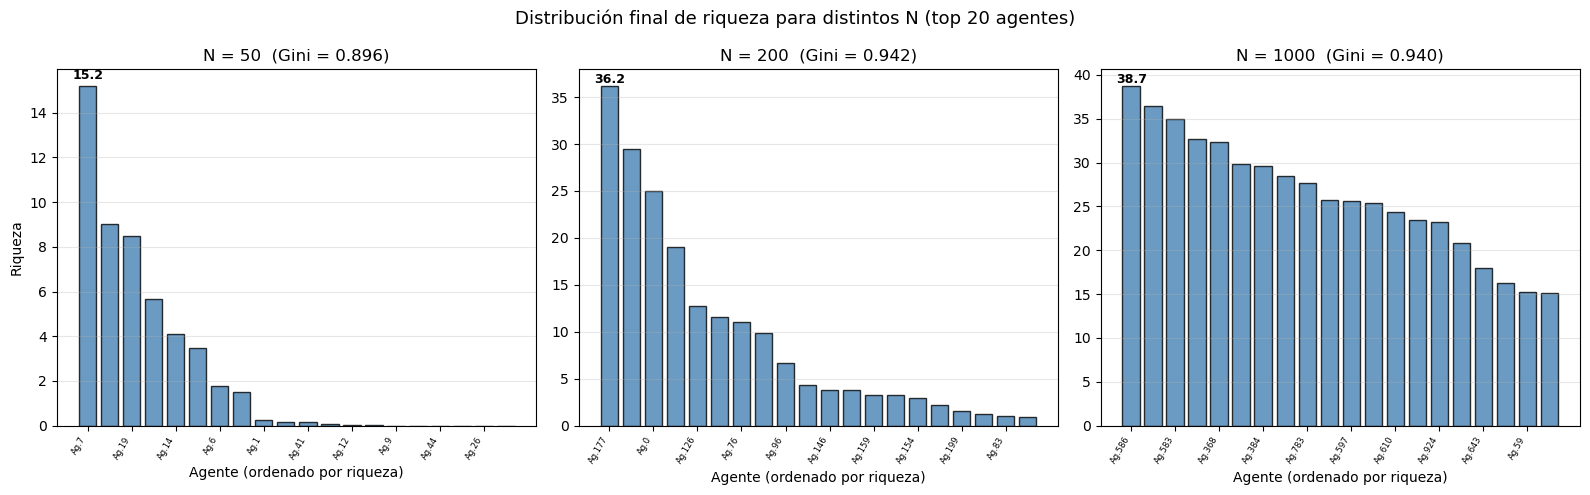

Resumen para distintos N:
  N =   50: Gini = 0.8960, w_max = 15.2031 (30.41% del total)
  N =  200: Gini = 0.9417, w_max = 36.1974 (18.10% del total)
  N = 1000: Gini = 0.9395, w_max = 38.7443 (3.87% del total)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx in range(len(valores_N)):
    N_val = valores_N[idx]
    w_data = w_distintos_N[idx]
    g_val = gini(w_data)

    # Ordenar de mayor a menor
    w_sorted_N = np.sort(w_data)[::-1]
    top_N = min(20, N_val)
    w_indices_N = np.argsort(w_data)[::-1]

    # Barras con los top 20 agentes
    top_labels = ['Ag.%d' % w_indices_N[r] for r in range(top_N)]
    axes[idx].bar(range(top_N), w_sorted_N[:top_N], color='steelblue', edgecolor='black', alpha=0.8)

    # Anotar el valor del más rico
    axes[idx].text(0, w_sorted_N[0] + 0.3, '%.1f' % w_sorted_N[0],
                   ha='center', fontsize=9, fontweight='bold')

    axes[idx].set_title('N = %d  (Gini = %.3f)' % (N_val, g_val), fontsize=12)
    axes[idx].set_xlabel('Agente (ordenado por riqueza)')
    if idx == 0:
        axes[idx].set_ylabel('Riqueza')
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Mostrar solo algunos ticks del eje X para que no se solapen
    if top_N <= 20:
        axes[idx].set_xticks(range(0, top_N, 2))
        axes[idx].set_xticklabels([top_labels[r] for r in range(0, top_N, 2)],
                                   rotation=60, fontsize=6, ha='right')

plt.suptitle('Distribución final de riqueza para distintos N (top 20 agentes)', fontsize=13)
plt.tight_layout()
plt.show()

# Imprimir resumen
print('Resumen para distintos N:')
for idx in range(len(valores_N)):
    N_val = valores_N[idx]
    w_data = w_distintos_N[idx]
    w_max_N = np.max(w_data)
    frac_N = w_max_N / np.sum(w_data)
    print('  N = %4d: Gini = %.4f, w_max = %.4f (%.2f%% del total)' % (N_val, gini(w_data), w_max_N, 100*frac_N))

**Observación:** Los tres paneles muestran la distribución final de riqueza para N = 50, 200 y 1000, usando el mismo formato que el ejercicio 1 (los 20 agentes más ricos ordenados de mayor a menor).

En los tres casos se observa el mismo patrón de concentración extrema: unos pocos agentes acumulan la mayor parte de la riqueza y la gran mayoría no tiene prácticamente nada. Los coeficientes de Gini finales son muy similares (N=50: 0.8960, N=200: 0.9417, N=1000: 0.9395), lo que confirma que el fenómeno de condensación **no depende del tamaño del sistema**. No es un artefacto de tener pocos agentes: ya sea con 50 o con 1000, la riqueza termina concentrándose igualmente.

---
## Ejercicio 3: Histogramás de riqueza en distintos instantes

Los histogramás nos permiten ver como cambia la "forma" de la distribución de
riqueza a lo largo del tiempo. Es una de las formás más intuitivas de entender
lo que está pasando en el sistema.

Hemos guardado snapshots del vector completo de riquezas en seis momentos
distintos: al principio (t = 0), y después de 1.000, 10.000, 50.000, 100.000
y 200.000 transacciones. Para cada uno construimos un histograma y marcamos
la media (linea roja) y la mediana (linea naranja).

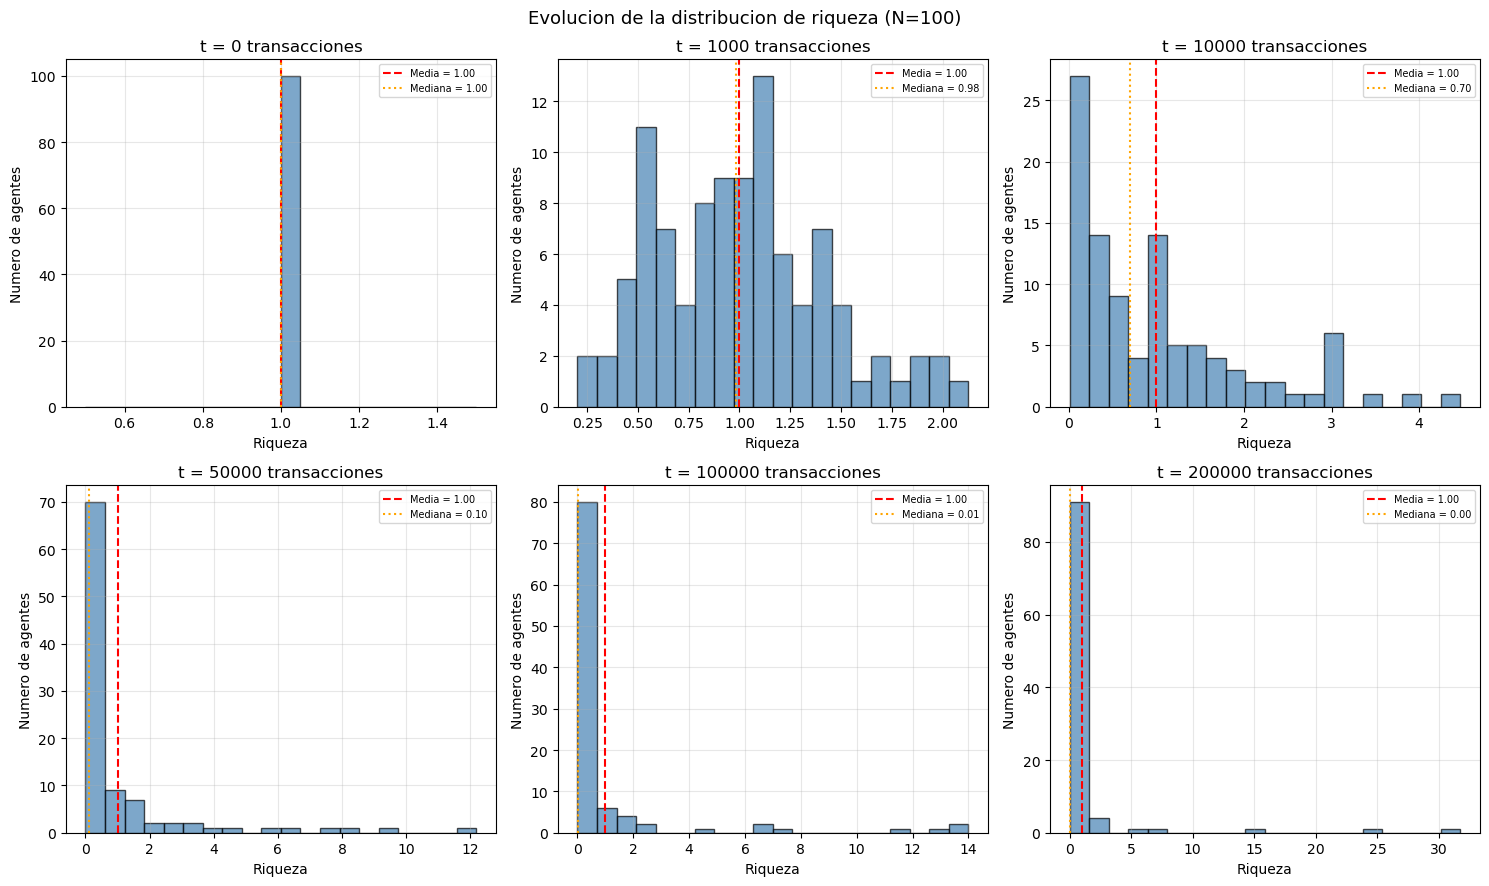

In [9]:
instantes = [0, 1000, 10000, 50000, 100000, 200000]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx in range(len(snapshots)):
    w_snap = snapshots[idx]
    axes[idx].hist(w_snap, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title('t = ' + str(instantes[idx]) + ' transacciones')
    axes[idx].set_xlabel('Riqueza')
    axes[idx].set_ylabel('Numero de agentes')
    axes[idx].axvline(np.mean(w_snap), color='red', linestyle='--',
                       label='Media = %.2f' % np.mean(w_snap))
    axes[idx].axvline(np.median(w_snap), color='orange', linestyle=':',
                       label='Mediana = %.2f' % np.median(w_snap))
    axes[idx].legend(fontsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Evolucion de la distribucion de riqueza (N=100)', fontsize=13)
plt.tight_layout()
plt.show()

**Descripción de la evolución:**

Los seis histogramás muestran una transformación progresiva de la distribución de riqueza:

- En **t = 0** todos tienen riqueza 1. Media y mediana coinciden en 1.0.

- En **t = 1.000** la distribución se ha ensanchado ligeramente. La mediana apenas ha bajado a 0.9844, prácticamente igual a la media (1.0). Las diferencias son todavia moderadas.

- En **t = 10.000** la asimetría es ya visible: la mediana ha caido a 0.6952, notablemente por debajo de la media (1.0). Esto significa que más de la mitad de los agentes tienen menos que el promedio.

- En **t = 50.000** la distribución ha cambiado cualitativamente. La mediana es 0.0978, casi diez veces menor que la media. La gran mayoria de agentes está arrinconada cerca de cero.

- En **t = 100.000** la concentración es extrema: la mediana es 0.0083, cien veces menor que la media. Prácticamente todos los agentes están en la primera barra del histograma.

- Al final (**t = 200.000**) la mediana es 0.0001, diez mil veces menor que la media. Toda la riqueza está en manos de uno o dos agentes.

La progresiva separación entre media y mediana es la firma cuantitativa de la desigualdad creciente: cuando la mediana es mucho menor que la media, más de la mitad de la población tiene menos que el promedio.

---
## Ejercicio 4: Evolución de la riqueza máxima del sistema

Ahora vamos a mirar directamente cuánto tiene el agente más rico a lo largo del
tiempo. Esto nos da una idea de como de rápido se produce la concentración.

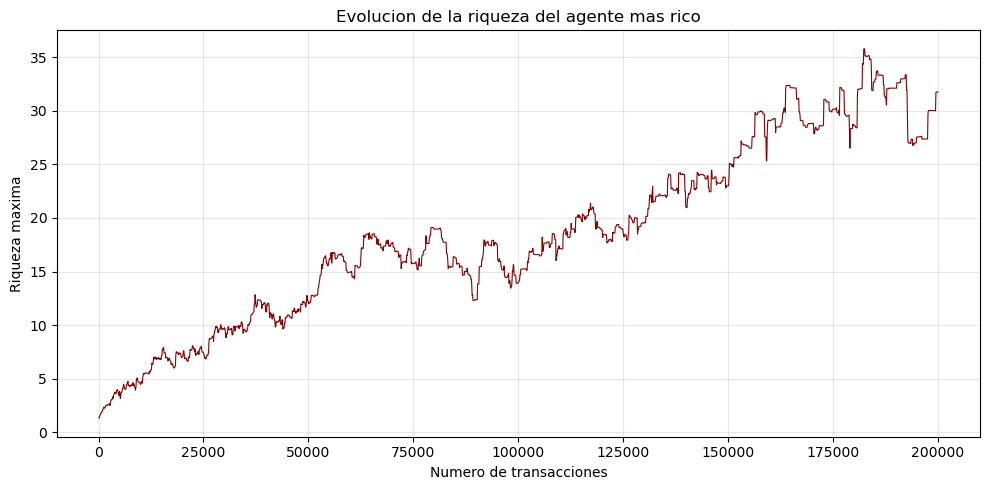

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(tiempos, hist_max, color='darkred', linewidth=0.8)
plt.xlabel('Numero de transacciones')
plt.ylabel('Riqueza maxima')
plt.title('Evolucion de la riqueza del agente mas rico')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observación:** La riqueza máxima crece desde 1.0 hasta 31.7418 a lo largo de las 200.000 transacciones, pero de forma muy irregular. En t = 25.000 es 7.40, en t = 50.000 es 12.19, en t = 100.000 baja a 14.00 (crecimiento lento en esa fase), y luego sube a 23.00 en t = 150.000 antes de alcanzar 31.74 al final.

La curva tiene un caracter marcadamente volatil, con subidas y bajadas bruscas típicas de un proceso estocástico. Esto se debe a que incluso el agente más rico puede perder transacciones consecutivas que reducen temporalmente su riqueza, y a que la identidad del agente más rico puede cambiar a lo largo del tiempo.

---
## Ejercicio 5: Fracción de riqueza del agente más rico

Complementamos el gráfico anterior representando la fracción de la riqueza total
que posee el agente más rico (es decir, w_max / W_total). Esto nos dice que
porcentaje del "pastel" se lleva el más afortunado. Incluimos una linea de
referencia en 1/N = 0.01, que seria el valor correspondiente a igualdad perfecta.

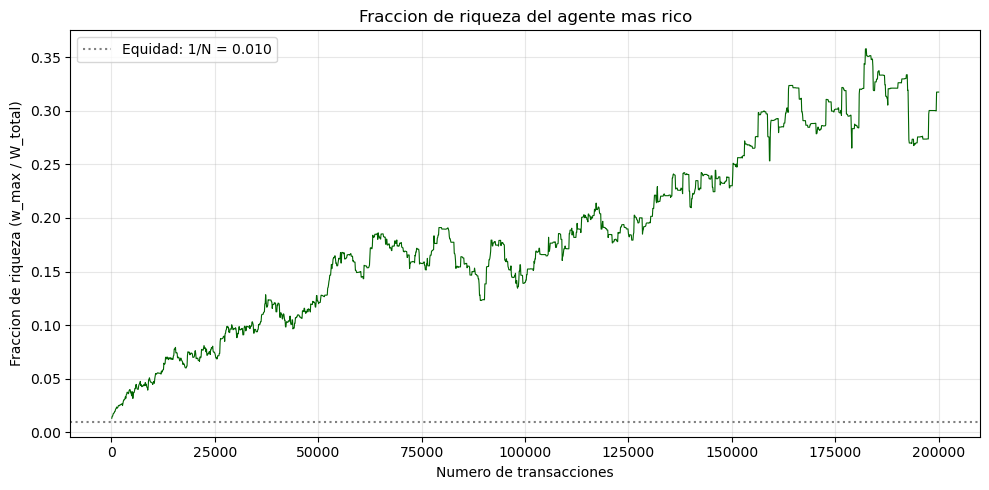

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(tiempos, hist_frac, color='darkgreen', linewidth=0.8)
plt.xlabel('Numero de transacciones')
plt.ylabel('Fraccion de riqueza (w_max / W_total)')
plt.title('Fraccion de riqueza del agente mas rico')
plt.axhline(1.0/N, color='gray', linestyle=':', label='Equidad: 1/N = %.3f' % (1.0/N))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observación:** Partiendo de una fracción del 1% (1/N = 0.01, marcada con la linea punteada), la fracción de riqueza del agente más rico crece de forma sostenida:

- En t = 50.000: el más rico posee el 12.19% (fracción = 0.1219)
- En t = 100.000: posee el 14.00% (fracción = 0.1400)
- En t = 150.000: posee el 23.00% (fracción = 0.2300)
- En t = 200.000: posee el 31.74% (fracción = 0.3174)

Un solo individuo, sin ninguna ventaja sobre los demas, acaba poseyendo casi un tercio de toda la riqueza del sistema. Si la simulación continuase, está fracción seguiria creciendo hasta acercarse al 100%, ya que el modelo tiende asintoticamente a la concentración total.

---
## Ejercicio 6: Coeficiente de Gini

El coeficiente de Gini nos permite cuantificar la desigualdad de forma rigurosa
a lo largo de toda la simulación. Mientras que los histogramás muestran la "foto"
en instantes concretos, el Gini nos da la "pelicula" completa.

Recordemos: Gini = 0 es igualdad perfecta, Gini cercano a 1 es desigualdad total.

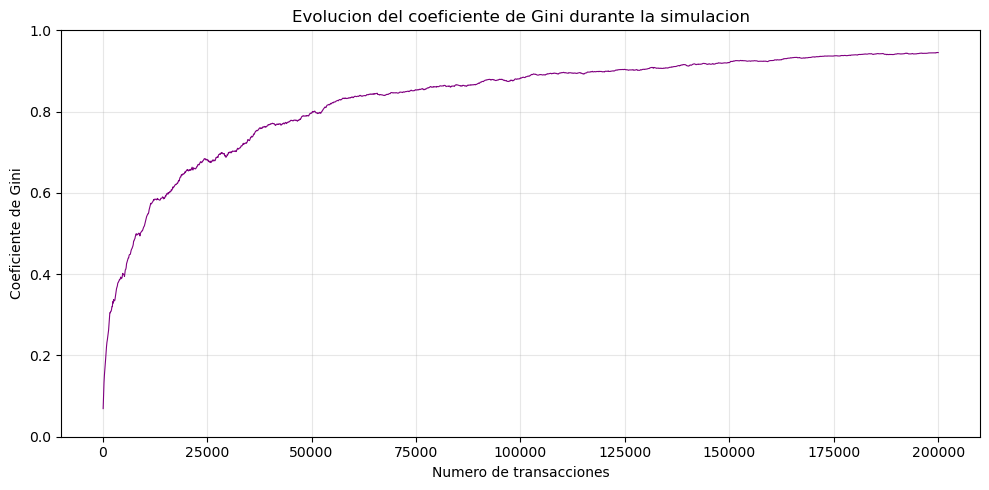

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(tiempos, hist_gini_arr, color='purple', linewidth=0.8)
plt.xlabel('Numero de transacciones')
plt.ylabel('Coeficiente de Gini')
plt.title('Evolucion del coeficiente de Gini durante la simulacion')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observación:** El Gini parte de un valor cercano a 0 y crece de forma monotona y suave. La evolución temporal muestra dos fases claras:

- **Fase rápida** (t = 0 a ~50.000): el Gini crece rápidamente. En t = 5.000 ya vale 0.3991, en t = 10.000 alcanza 0.5200, en t = 25.000 llega a 0.6804, y en t = 50.000 es 0.7967. En las primeras 50.000 transacciones se genera el 80% de la desigualdad total.

- **Fase de saturación** (t = 50.000 a 200.000): el crecimiento se ralentiza. En t = 100.000 el Gini es 0.8830, en t = 150.000 es 0.9208, y al final es 0.9453. Cuando la mayor parte de la riqueza ya está concentrada, las transacciones entre agentes pobres involucran cantidades minusculas y apenas cambian la distribución.

A diferencia de las curvas de riqueza máxima (ejercicio 4), que son muy volatiles, el Gini es notablemente suave porque es una medida global que promedia sobre todos los agentes.

---
## Ejercicio 7: Evolución individual de agentes seleccionados

Hasta ahora hemos mirado el sistema de forma global (distribución, máximos, Gini).
Pero también es interesante seguir la historia de agentes concretos.

Hemos elegido 5 agentes (con índices 0, 10, 25, 50 y 75) y registrado su riqueza
a lo largo de toda la simulación. Todos empiezan con riqueza 1. Veamos qué les pasa.

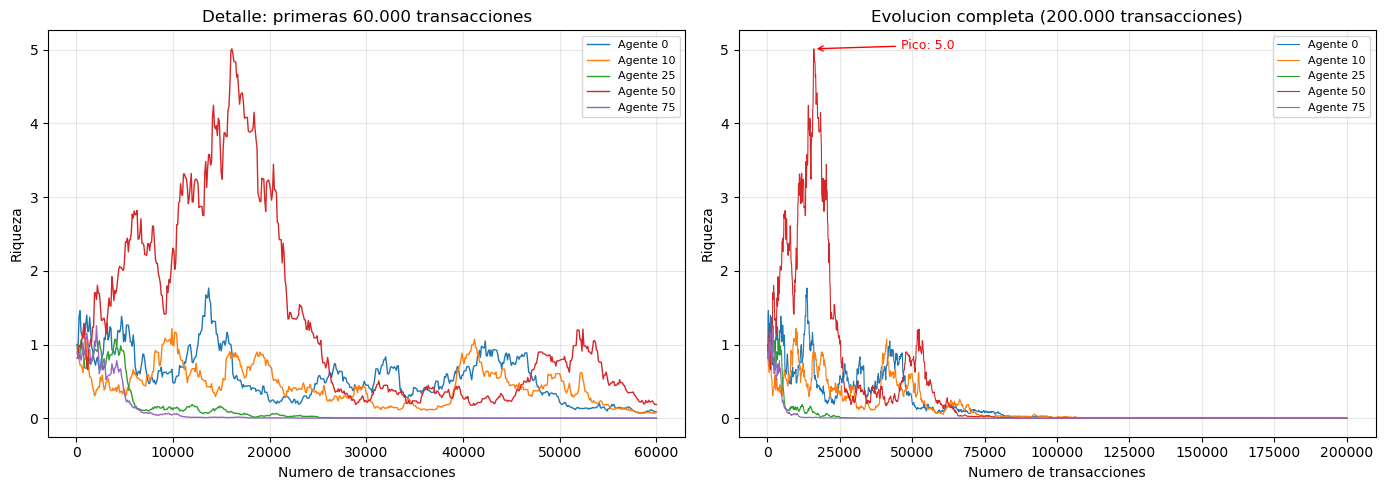

Picos de riqueza de los agentes seguidos:
  Agente  0: pico = 1.7672 en t = 13700, riqueza final = 0.000231
  Agente 10: pico = 1.2182 en t = 9900, riqueza final = 0.000412
  Agente 25: pico = 1.0731 en t = 4000, riqueza final = 0.000000
  Agente 50: pico = 5.0131 en t = 16100, riqueza final = 0.000000
  Agente 75: pico = 1.2520 en t = 2100, riqueza final = 0.000000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: zoom a las primeras 60.000 transacciones
for s in range(n_seg):
    mask = tiempos <= 60000
    axes[0].plot(tiempos[mask], hist_agentes[s][mask],
                 label='Agente %d' % agentes_seg[s], linewidth=1.0)
axes[0].set_xlabel('Numero de transacciones')
axes[0].set_ylabel('Riqueza')
axes[0].set_title('Detalle: primeras 60.000 transacciones')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel derecho: vista completa con anotacion del pico del Agente 50
for s in range(n_seg):
    axes[1].plot(tiempos, hist_agentes[s],
                 label='Agente %d' % agentes_seg[s], linewidth=0.8)
# Anotar el pico mas alto (Agente 50)
traj_50 = hist_agentes[3]  # agentes_seg[3] = 50
peak_idx = np.argmax(traj_50)
peak_t = tiempos[peak_idx]
peak_v = traj_50[peak_idx]
axes[1].annotate('Pico: %.1f' % peak_v,
                 xy=(peak_t, peak_v), xytext=(peak_t + 30000, peak_v),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=9, color='red')
axes[1].set_xlabel('Numero de transacciones')
axes[1].set_ylabel('Riqueza')
axes[1].set_title('Evolucion completa (200.000 transacciones)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir picos
print('Picos de riqueza de los agentes seguidos:')
for s in range(n_seg):
    traj = hist_agentes[s]
    p_val = np.max(traj)
    p_idx = int(np.argmax(traj))
    p_t = int(tiempos[p_idx])
    print('  Agente %2d: pico = %.4f en t = %d, riqueza final = %.6f' % (agentes_seg[s], p_val, p_t, traj[-1]))

**Observación:** El panel izquierdo muestra un **zoom a las primeras 60.000 transacciones**, donde ocurre toda la acción. Se aprecia como el Agente 50 (rosa) alcanza un pico de 5.01 unidades en t = 16.100, pero después se derrumba. Los demás agentes muestran oscilaciones más modestas antes de caer.

El panel derecho muestra la evolución completa (200.000 transacciones). A partir de t ~ 75.000, todos los agentes seguidos tienen riqueza nula: han sido absorbidos por la dinámica del sistema. El agente que acaba con la riqueza (agente 76, con 31.74 unidades) no está entre los seguidos.

---
## Ejercicio 8: Transacciones ganadas y perdidas

Este ejercicio es probablemente el más revelador de todo el proyecto. Vamos a
comprobar si la desigualdad se debe a que algunos agentes "ganan mas" que otros,
o si hay algo más sutil en juego.

Para ello, contamos cuántas transacciones ha ganado y cuántas ha perdido cada uno
de los 5 agentes que estamos siguiendo. Si la moneda es justa, esperariamos un
ratio de victorias/derrotas cercano a 1 para todos.

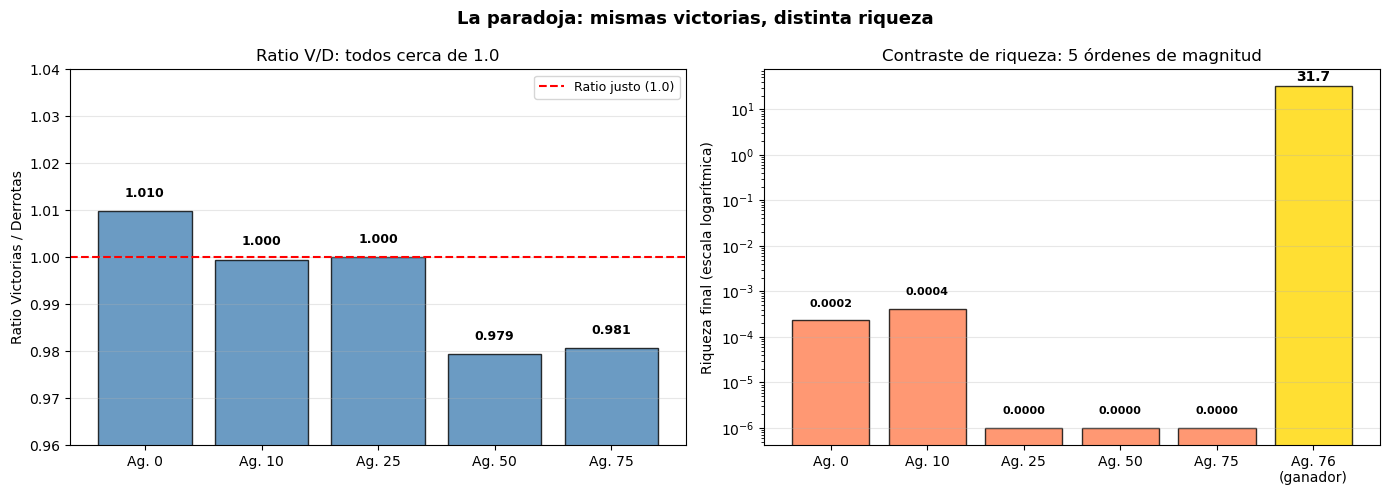

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: ratio V/D de cada agente seguido
ratios_vd = []
for s in range(n_seg):
    r = wins[s] / derrotas[s] if derrotas[s] > 0 else 1.0
    ratios_vd.append(r)
labels_ag = ['Ag. %d' % agentes_seg[s] for s in range(n_seg)]
bars1 = axes[0].bar(labels_ag, ratios_vd, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Ratio justo (1.0)')
axes[0].set_ylabel('Ratio Victorias / Derrotas')
axes[0].set_title('Ratio V/D: todos cerca de 1.0')
axes[0].set_ylim(0.96, 1.04)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
for s in range(n_seg):
    axes[0].text(s, ratios_vd[s] + 0.003, '%.3f' % ratios_vd[s], ha='center', fontsize=9, fontweight='bold')

# Panel derecho: riqueza final en ESCALA LOG para ver el contraste
w_finals = [w[agentes_seg[s]] for s in range(n_seg)]
w_ganador = np.max(w)
ag_ganador = int(np.argmax(w))
all_vals = w_finals + [w_ganador]
# Reemplazar ceros por valor muy pequeño para que funcione el log
all_vals_log = [max(v, 1e-6) for v in all_vals]
all_labels = labels_ag + ['Ag. %d\n(ganador)' % ag_ganador]
all_colors = ['coral'] * n_seg + ['gold']
axes[1].bar(all_labels, all_vals_log, color=all_colors, edgecolor='black', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_ylabel('Riqueza final (escala logarítmica)')
axes[1].set_title('Contraste de riqueza: 5 órdenes de magnitud')
axes[1].grid(True, alpha=0.3, axis='y')
# Anotar valores exactos encima de cada barra
for s in range(n_seg):
    axes[1].text(s, all_vals_log[s] * 2, '%.4f' % w_finals[s], ha='center', fontsize=8, fontweight='bold')
axes[1].text(n_seg, w_ganador * 1.3, '%.1f' % w_ganador, ha='center', fontsize=10, fontweight='bold')

plt.suptitle('La paradoja: mismas victorias, distinta riqueza', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Tabla resumen
print('%8s %10s %10s %10s %14s' % ('Agente', 'Victorias', 'Derrotas', 'Ratio V/D', 'Riqueza final'))
print('-' * 56)
for s in range(n_seg):
    v = int(hist_wins[s, -1])
    d = int(hist_losses[s, -1])
    ratio = v / d if d > 0 else 0
    print('%8d %10d %10d %10.3f %14.4f' % (agentes_seg[s], v, d, ratio, w[agentes_seg[s]]))

  Agente  Victorias   Derrotas  Ratio V/D  Riqueza final
--------------------------------------------------------
       0       2046       2026      1.010         0.0002
      10       2045       2046      1.000         0.0004
      25       1955       1955      1.000         0.0000
      50       1903       1943      0.979         0.0000
      75       1973       2012      0.981         0.0000


**Observación clave - La paradoja:** El panel izquierdo muestra los ratios Victoria/Derrota de los 5 agentes seguidos. Todos están entre 0.979 y 1.010, prácticamente iguales a 1.0 (la línea roja). **La moneda es justa y se nota: todos ganan y pierden lo mismo.**

El panel derecho muestra la riqueza final de esos mismos agentes comparada con la del ganador (agente 76), usando **escala logarítmica** para que todas las barras sean visibles. El contraste es de 5 órdenes de magnitud: los agentes seguidos tienen riquezas de 0.0002 o 0.0000, mientras que el agente 76 acumula 31.7 unidades. La escala log permite apreciar esta diferencia abismal que en escala lineal sería invisible.

La desigualdad no surge porque unos ganen más transacciones que otros, sino porque el **impacto relativo** de cada transacción es asimétrico: perder cuando eres pobre te arruina proporcionalmente; perder cuando eres rico no te afecta.

---
## Ejercicio 9: Modelo con redistribución (impuestos)

Acabamos de ver que el modelo básico conduce inevitablemente a la concentración
total de riqueza. La pregunta natural es: ¿se puede hacer algo para evitarlo?

En este ejercicio introducimos un mecanismo de **redistribución** inspirado en
los impuestos. La idea es sencilla: cada N transacciones (es decir, una vez por
ronda), le quitamos a cada agente una fracción tau de su riqueza, sumamos todo
lo recaudado, y lo repartimos a partes iguales entre todos.

Este mecanismo conserva la riqueza total (lo que se quita a unos se da a otros)
y actua como una "fuerza restauradora" que empuja hacia la igualdad. Vamos a
ver si es efectivo, probando con tres tasas impositivas: tau = 0.01 (muy suave),
0.05 (moderada) y 0.10 (alta).

In [16]:
def simular_redistribucion(N, epsilon, n_trans, tasa, periodo, registrar_cada):
    """Modelo yard-sale con redistribucion periodica.
    Devuelve (w_final, tiempos, hist_gini)."""
    w = np.ones(N)
    W_total = np.sum(w)
    n_reg = n_trans // registrar_cada
    tiempos = np.zeros(n_reg)
    hist_gini = np.zeros(n_reg)

    reg = 0
    for t in range(1, n_trans + 1):
        # Transaccion yard-sale normal
        i, j = np.random.choice(N, size=2, replace=False)
        dw = epsilon * min(w[i], w[j])
        if np.random.random() < 0.5:
            w[i] = w[i] + dw
            w[j] = w[j] - dw
        else:
            w[i] = w[i] - dw
            w[j] = w[j] + dw

        # Redistribucion periodica: 
        #   cada cierto tiempo se aplica un impuesto 
        #   a cada aganete se le quita el mismo % de su riqueza  
        #   se suma todo lo recaudado 
        #   se reparte por partes iguales entre todos
        if t % periodo == 0:
            recaudado = tasa * np.sum(w)
            w = w * (1 - tasa)
            w = w + recaudado / N

        if t % registrar_cada == 0:
            tiempos[reg] = t
            hist_gini[reg] = gini(w)
            reg = reg + 1

    return w, tiempos, hist_gini

In [17]:
# Comparar distintas tasas de redistribucion
tasas = [0.01, 0.05, 0.10]

w_redist = []
t_redist = []
g_redist = []

for tasa in tasas:
    w_r, t_r, g_r = simular_redistribucion(N, epsilon, n_trans, tasa, N, N)
    w_redist.append(w_r)
    t_redist.append(t_r)
    g_redist.append(g_r)
    print('tau = %.2f | Gini final = %.4f' % (tasa, gini(w_r)))

tau = 0.01 | Gini final = 0.3985
tau = 0.05 | Gini final = 0.2027
tau = 0.10 | Gini final = 0.1293


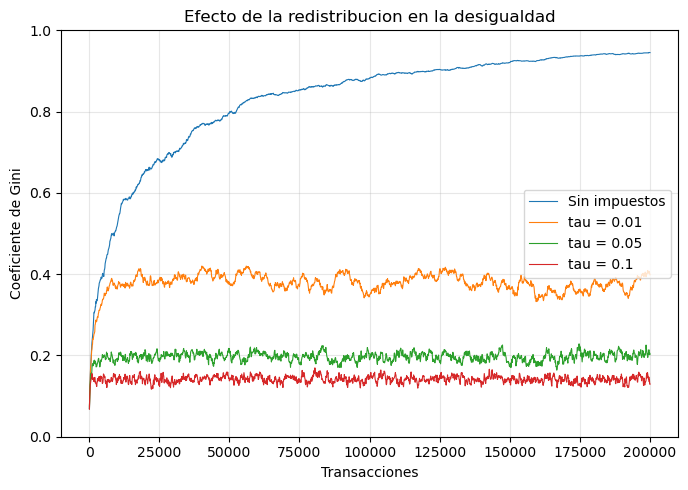

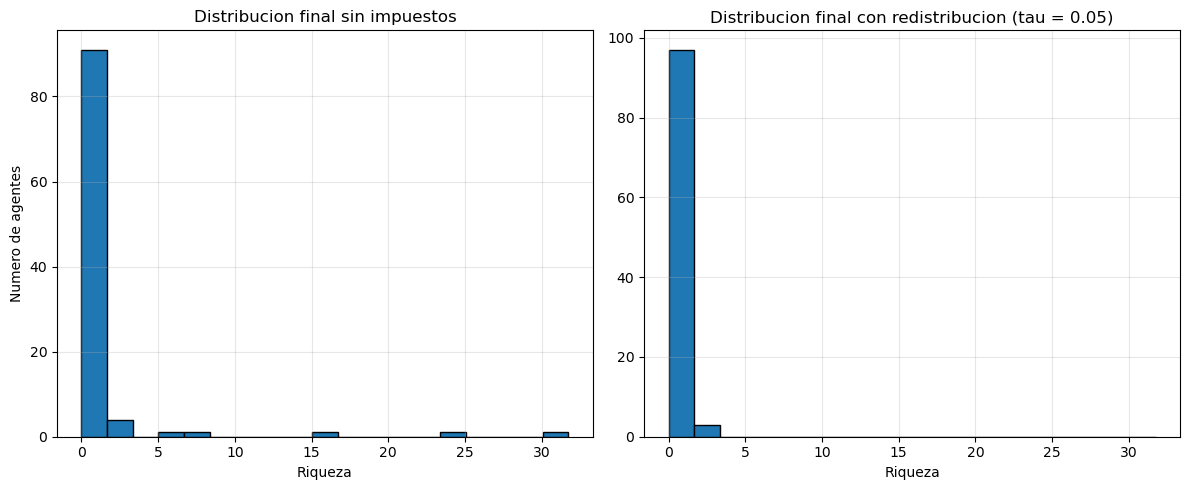

In [18]:
# ----------------------------
# FIGURA 1: evolucion del Gini
# ----------------------------
plt.figure(figsize=(7, 5))

plt.plot(tiempos, hist_gini_arr, label='Sin impuestos', linewidth=0.8)
for idx in range(len(tasas)):
    plt.plot(t_redist[idx], g_redist[idx],
             label='tau = ' + str(tasas[idx]), linewidth=0.8)

plt.xlabel('Transacciones')
plt.ylabel('Coeficiente de Gini')
plt.title('Efecto de la redistribucion en la desigualdad')
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------
# FIGURA 2: dos histogramas por separado
# -----------------------------------------

# w = caso sin impuestos
# w_redist[1] = caso tau = 0.05, porque tasas = [0.01, 0.05, 0.10]

max_riqueza = max(np.max(w), np.max(w_redist[1]))
bins = np.linspace(0, max_riqueza, 20)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma sin impuestos
axes[0].hist(w, bins=bins, edgecolor='black')
axes[0].set_title('Distribucion final sin impuestos')
axes[0].set_xlabel('Riqueza')
axes[0].set_ylabel('Numero de agentes')
axes[0].grid(True, alpha=0.3)

# Histograma con redistribucion
axes[1].hist(w_redist[1], bins=bins, edgecolor='black')
axes[1].set_title('Distribucion final con redistribucion (tau = 0.05)')
axes[1].set_xlabel('Riqueza')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## IMPORTANTE !! --> No estan compartiendo el eje Y los histogramas porque si lo comparten, en el de la derecha SOLO sale la barra más alta (la de la izquierda)

**Observación:** El efecto de la redistribución es espectacular. Los valores finales del Gini son:

- Sin impuestos: Gini = 0.95 (curva azul, desigualdad extrema)
- tau = 0.01 (1%): Gini = **0.3985** (reducción del 58%)
- tau = 0.05 (5%): Gini = **0.2027** (sociedad relativamente equitativa)
- tau = 0.10 (10%): Gini = **0.1293** (cercano a igualdad perfecta)

El panel izquierdo muestra como las curvas con impuestos se estabilizan rápidamente en valores bajos, mientras que sin impuestos el Gini se dispara. El panel derecho contrasta las distribuciones finales: sin impuestos toda la riqueza está en un agente; con redistribución se reparte de forma mucho más uniforme.

Es notable que incluso una tasa tan baja como el 1% ya tiene un efecto enorme: baja el Gini de 0.95 a 0.40. Si la concentración es un fenómeno estadisticamente inevitable, los mecanismos redistributivos son una herramienta estructuralmente necesaria para mantener el equilibrio del sistema.

---
## Ejercicio 10: Interacciones limitadas a vecinos proximos

Otra forma de modificar el modelo es cambiar **quien puede interactuar con quien**.
En el modelo básico, cualquier agente puede comerciar con cualquier otro. Pero en
la vida real, un pequeno comerciante no compite directamente con una gran
multinacional.

En este ejercicio, ordenamos a los agentes por riqueza y solo permitimos que cada
uno interactue con su vecino inmediato en esa ordenación (el que tiene riqueza
justo por encima o justo por debajo). De está forma, los agentes solo compiten
con otros que tienen una riqueza similar a la suya.

Esto deberia reducir la asimetría del intercambio, ya que cuando dos agentes tienen
riqueza parecida, min(w_i, w_j) es similar para ambos, y por tanto las perdidas
relativas son más equilibradas.

In [19]:
def simular_vecinos(N, epsilon, n_trans, k, registrar_cada):
    """Modelo yard-sale con interacciones limitadas a vecinos
    en la ordenacion por riqueza. Devuelve (w_final, tiempos, hist_gini)."""
    w = np.ones(N)
    W_total = np.sum(w)
    n_reg = n_trans // registrar_cada
    tiempos = np.zeros(n_reg)
    hist_gini = np.zeros(n_reg)

    reg = 0
    for t in range(1, n_trans + 1):
        # Ordenar agentes por riqueza
        orden = np.argsort(w)

        # Seleccionar una posicion al azar en la ordenacion
        pos_i = np.random.randint(0, N)

        # Buscar vecinos dentro del rango k
        pos_min = max(0, pos_i - k)
        pos_max = min(N - 1, pos_i + k)
        posibles = []
        for pos in range(pos_min, pos_max + 1):
            if pos != pos_i:
                posibles.append(pos)
        if len(posibles) == 0:
            continue
        pos_j = posibles[np.random.randint(len(posibles))]

        i = orden[pos_i]
        j = orden[pos_j]

        # Transaccion
        dw = epsilon * min(w[i], w[j])
        if np.random.random() < 0.5:
            w[i] = w[i] + dw
            w[j] = w[j] - dw
        else:
            w[i] = w[i] - dw
            w[j] = w[j] + dw

        if t % registrar_cada == 0:
            tiempos[reg] = t
            hist_gini[reg] = gini(w)
            reg = reg + 1

    return w, tiempos, hist_gini

Vecinos (k=1): Gini final = 0.9900


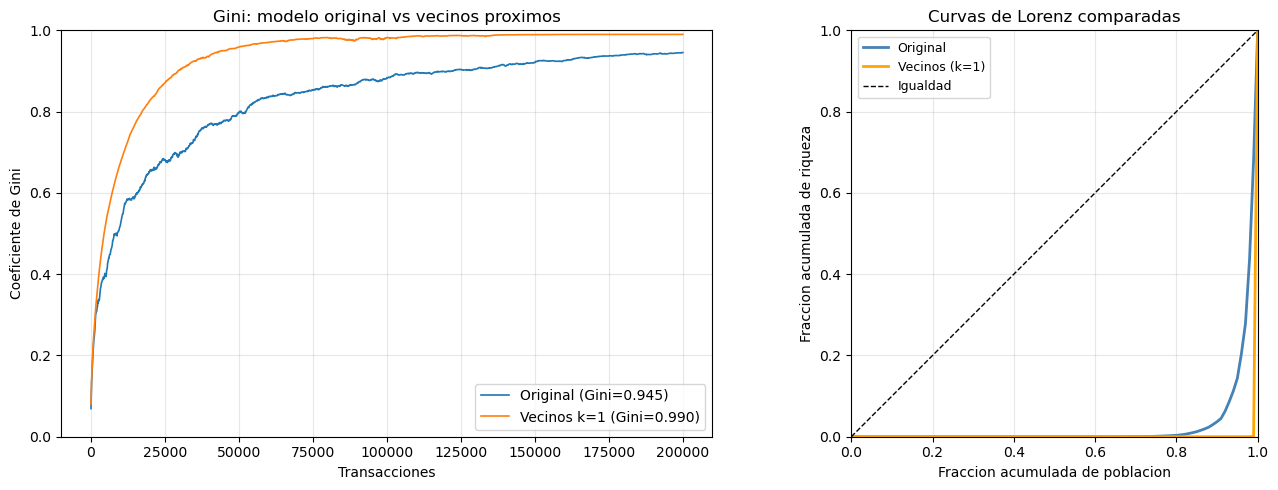

In [20]:
# Modelo con vecinos inmediatos (k=1)
w_vec1, t_vec1, g_vec1 = simular_vecinos(N, epsilon, n_trans, 1, N)
print('Vecinos (k=1): Gini final = %.4f' % gini(w_vec1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: evolucion del Gini
axes[0].plot(tiempos, hist_gini_arr, label='Original (Gini=%.3f)' % gini(w), linewidth=1.2)
axes[0].plot(t_vec1, g_vec1, label='Vecinos k=1 (Gini=%.3f)' % gini(w_vec1), linewidth=1.2)
axes[0].set_xlabel('Transacciones')
axes[0].set_ylabel('Coeficiente de Gini')
axes[0].set_title('Gini: modelo original vs vecinos proximos')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Panel derecho: curvas de Lorenz comparativas
for w_data, label, color in [(w, 'Original', 'steelblue'), (w_vec1, 'Vecinos (k=1)', 'orange')]:
    w_lorenz = np.sort(w_data)
    cum_w = np.cumsum(w_lorenz) / np.sum(w_lorenz)
    cum_pop = np.arange(1, len(w_data) + 1) / len(w_data)
    cum_w = np.insert(cum_w, 0, 0)
    cum_pop = np.insert(cum_pop, 0, 0)
    axes[1].plot(cum_pop, cum_w, label=label, linewidth=2, color=color)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Igualdad')
axes[1].set_xlabel('Fraccion acumulada de poblacion')
axes[1].set_ylabel('Fraccion acumulada de riqueza')
axes[1].set_title('Curvas de Lorenz comparadas')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

**Observación:** El panel izquierdo muestra que el modelo de vecinos (k=1, naranja) alcanza un Gini de 0.99, superior al 0.945 del modelo original (azul). La concentración es más rápida y más extrema.

El panel derecho lo confirma con las **curvas de Lorenz**: la curva del modelo de vecinos (naranja) está aun más pegada al eje horizontal que la del original, indicando mayor concentración. En el modelo de vecinos, los pobres quedan atrapados compitiendo entre ellos sin acceso a la riqueza de los ricos, y todas las transacciones son significativas para ambas partes.

---
## Ejercicio 11: Influencia del parámetro k

En el ejercicio anterior usamos k = 1 (solo vecinos inmediatos). Ahora vamos
a explorar qué pasa cuando ampliamos el rango de interacción. Con k = 3, cada
agente puede interactuar con los 3 más ricos y los 3 más pobres que el en la
ordenación. Con k = 50 (la mitad de N = 100), prácticamente puede interactuar
con cualquiera.

Esperamos que a medida que k aumente, el modelo se parezca cada vez más al
original. La pregunta es: ¿hay una transición brusca, o es gradual?

In [21]:
valores_k = [1, 3, 10, 25, 50]
w_k_list = []
t_k_list = []
g_k_list = []

for k_val in valores_k:
    w_k, t_k, g_k = simular_vecinos(N, epsilon, n_trans, k_val, N)
    w_k_list.append(w_k)
    t_k_list.append(t_k)
    g_k_list.append(g_k)
    print('k = %3d | Gini final = %.4f' % (k_val, gini(w_k)))

k =   1 | Gini final = 0.9900
k =   3 | Gini final = 0.9870
k =  10 | Gini final = 0.9762
k =  25 | Gini final = 0.9736
k =  50 | Gini final = 0.9512


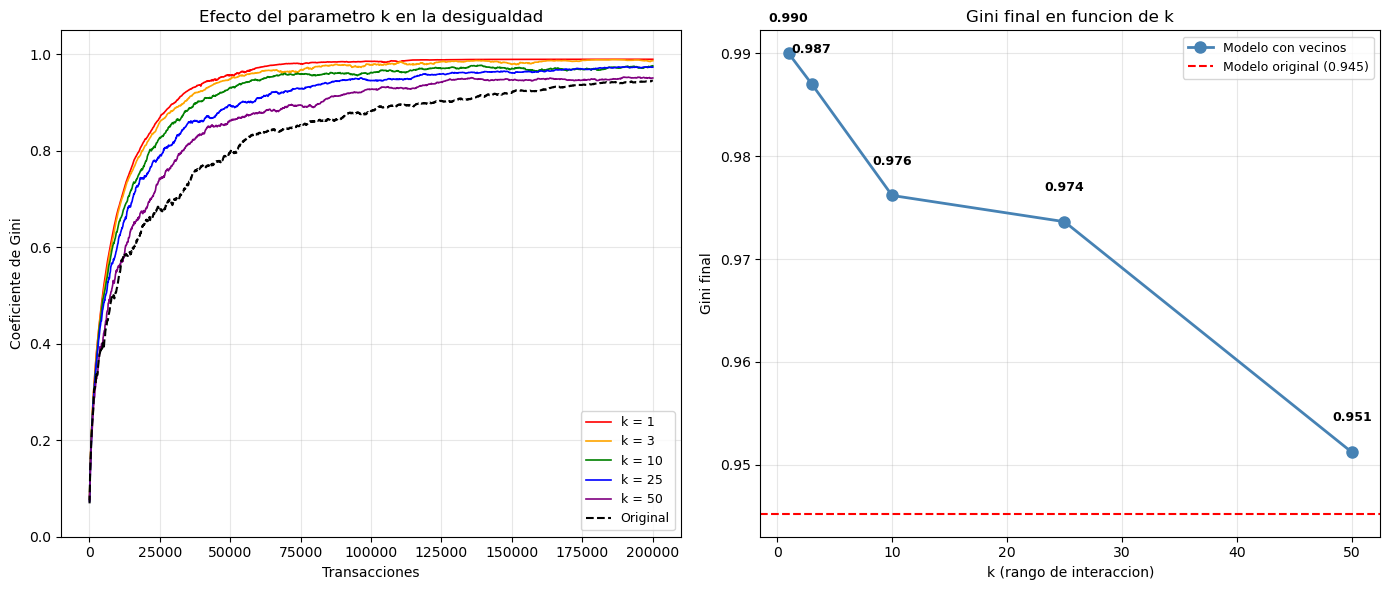

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: evolucion del Gini para distintos k
colores_k = ['red', 'orange', 'green', 'blue', 'purple']
for idx in range(len(valores_k)):
    axes[0].plot(t_k_list[idx], g_k_list[idx],
                 label='k = %d' % valores_k[idx], linewidth=1.2, color=colores_k[idx])
axes[0].plot(tiempos, hist_gini_arr,
             label='Original', linewidth=1.5, linestyle='--', color='black')
axes[0].set_xlabel('Transacciones')
axes[0].set_ylabel('Coeficiente de Gini')
axes[0].set_title('Efecto del parametro k en la desigualdad')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# Panel derecho: Gini final en funcion de k con valores anotados
ginis_k = [gini(w_k_list[idx]) for idx in range(len(valores_k))]
axes[1].plot(valores_k, ginis_k, 'o-', color='steelblue', markersize=8, linewidth=2, label='Modelo con vecinos')
axes[1].axhline(gini(w), color='red', linestyle='--', linewidth=1.5, label='Modelo original (%.3f)' % gini(w))
for idx in range(len(valores_k)):
    axes[1].text(valores_k[idx], ginis_k[idx] + 0.003, '%.3f' % ginis_k[idx],
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('k (rango de interaccion)')
axes[1].set_ylabel('Gini final')
axes[1].set_title('Gini final en funcion de k')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observación:** El panel izquierdo muestra la evolución del Gini para distintos k. Para todos los valores de k, el Gini final supera al del modelo original (linea negra discontinua).

El panel derecho muestra la relación entre k y el Gini final con los **valores exactos anotados**: k=1 -> 0.990, k=3 -> 0.987, k=10 -> 0.976, k=25 -> 0.974, k=50 -> 0.951. La linea roja marca el modelo original (0.945). La transición es gradual: a mayor k, más se acerca al comportamiento original.

---
## Ejercicio 12: Restricciones estructurales — Red aleatoria

Como ultima variante, vamos a explorar qué pasa cuando las interacciones entre
agentes no son completamente libres, sino que están definidas por una estructura
de red. En la vida real, no todos los agentes económicos están conectados entre
si: hay relaciones comerciales, redes de contacto, mercados locales...

Para modelar esto, usamos una **red aleatoria de Erdos-Renyi** (también llamada
red de Poisson), que es la más clásica en teoria de grafos. En está red, cada
par de agentes tiene una probabilidad p de estar conectado, y solo se permiten
transacciones entre agentes que están conectados.

Con p = 1.0 todos están conectados con todos (grafo completo) y recuperamos
el modelo original. Con p más bajo, la red es más dispersa y las interacciones
más limitadas.

In [23]:
def simular_red(N, epsilon, n_trans, prob_conexion, registrar_cada):
    """Modelo yard-sale sobre una red aleatoria Erdos-Renyi.
    Devuelve (w_final, tiempos, hist_gini, grado_medio)."""
    w = np.ones(N)
    W_total = np.sum(w)
    n_reg = n_trans // registrar_cada
    tiempos = np.zeros(n_reg)
    hist_gini = np.zeros(n_reg)

    # Generar red aleatoria simetrica
    adj = np.random.random((N, N)) < prob_conexion
    np.fill_diagonal(adj, False)
    adj = np.triu(adj, k=1)
    adj = adj | adj.T

    # Lista de vecinos por agente
    vecinos = []
    for a in range(N):
        vecinos.append(list(np.where(adj[a])[0]))
    grado_medio = np.mean([len(vecinos[a]) for a in range(N)])

    reg = 0
    for t in range(1, n_trans + 1):
        # Seleccionar un agente que tenga vecinos
        intentos = 0
        while intentos < 20:
            i = np.random.randint(N)
            if len(vecinos[i]) > 0:
                break
            intentos = intentos + 1
        if intentos == 20:
            continue

        j = vecinos[i][np.random.randint(len(vecinos[i]))]

        dw = epsilon * min(w[i], w[j])
        if np.random.random() < 0.5:
            w[i] = w[i] + dw
            w[j] = w[j] - dw
        else:
            w[i] = w[i] - dw
            w[j] = w[j] + dw

        if t % registrar_cada == 0:
            tiempos[reg] = t
            hist_gini[reg] = gini(w)
            reg = reg + 1

    return w, tiempos, hist_gini, grado_medio

In [24]:
probs = [0.05, 0.2, 0.5, 1.0]
w_red_list = []
t_red_list = []
g_red_list = []
grados = []

for p_val in probs:
    w_r, t_r, g_r, gm = simular_red(N, epsilon, n_trans, p_val, N)
    w_red_list.append(w_r)
    t_red_list.append(t_r)
    g_red_list.append(g_r)
    grados.append(gm)
    print('p = %.2f | Grado medio = %.1f | Gini final = %.4f' % (p_val, gm, gini(w_r)))

p = 0.05 | Grado medio = 5.0 | Gini final = 0.8416
p = 0.20 | Grado medio = 20.4 | Gini final = 0.8960
p = 0.50 | Grado medio = 49.0 | Gini final = 0.9290
p = 1.00 | Grado medio = 99.0 | Gini final = 0.9124


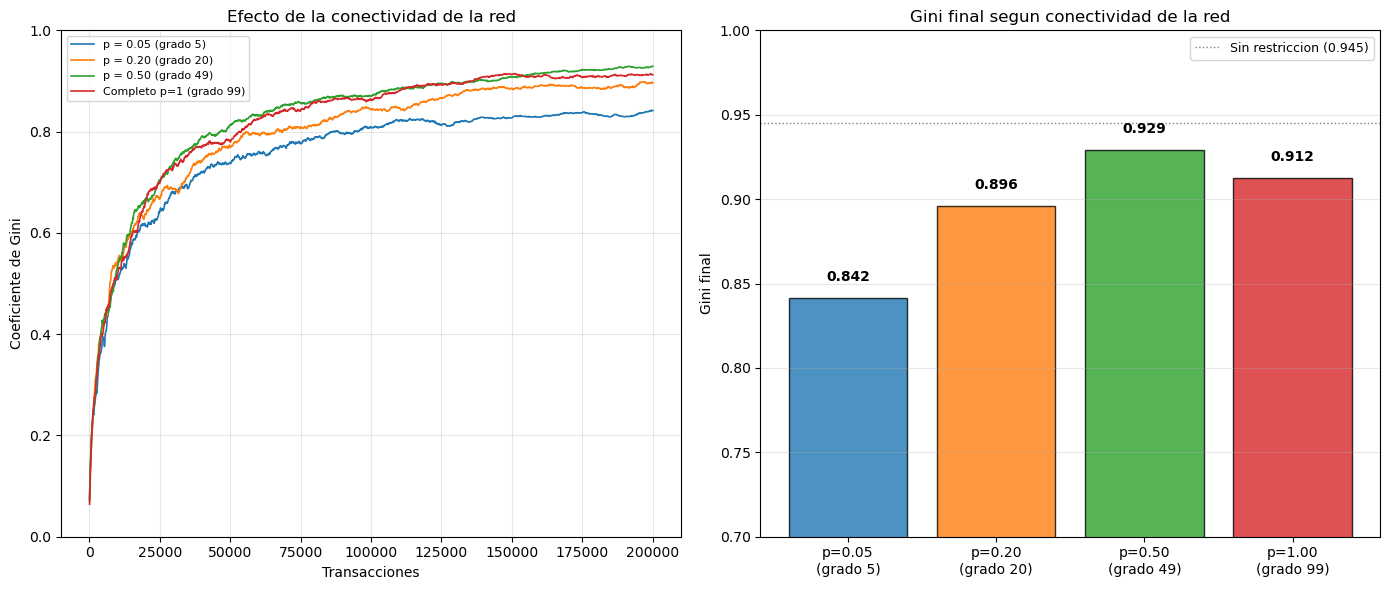

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: evolucion del Gini
for idx in range(len(probs)):
    if probs[idx] < 1.0:
        label = 'p = %.2f (grado %.0f)' % (probs[idx], grados[idx])
    else:
        label = 'Completo p=1 (grado %.0f)' % grados[idx]
    axes[0].plot(t_red_list[idx], g_red_list[idx], label=label, linewidth=1.2)
axes[0].set_xlabel('Transacciones')
axes[0].set_ylabel('Coeficiente de Gini')
axes[0].set_title('Efecto de la conectividad de la red')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Panel derecho: grafico de barras Gini final vs p
ginis_red = [gini(w_red_list[idx]) for idx in range(len(probs))]
x_labels = ['p=%.2f\n(grado %.0f)' % (probs[idx], grados[idx]) for idx in range(len(probs))]
colores_red = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars_red = axes[1].bar(x_labels, ginis_red, color=colores_red, edgecolor='black', alpha=0.8)
axes[1].axhline(gini(w), color='gray', linestyle=':', linewidth=1, label='Sin restriccion (%.3f)' % gini(w))
for idx in range(len(probs)):
    axes[1].text(idx, ginis_red[idx] + 0.01, '%.3f' % ginis_red[idx],
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Gini final')
axes[1].set_title('Gini final segun conectividad de la red')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.7, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Observación:** El panel izquierdo muestra la evolución del Gini para distintas probabilidades de conexión. Redes más dispersas (p bajo) producen condensación más lenta.

El panel derecho muestra el **Gini final para cada nivel de conectividad**, con valores exactos anotados. Se aprecia claramente que a menor conectividad, menor Gini final: p=0.05 produce Gini=0.84, mientras que p=0.50 llega a 0.93.

**Conclusión de los ejercicios 10-12:** el modelo de vecinos acelera la concentración (Gini 0.99), la red dispersa la ralentiza (Gini 0.84), pero ninguna la elimina. Solo la redistribución (ejercicio 9) la contrarrestá eficazmente.

---
# Discusión y reflexiones

En está sección respondemos a las tres cuestiones de reflexión planteadas en el
enunciado del proyecto. Son preguntas abiertas que invitan a pensar sobre el
significado de los resultados que hemos obtenido y sus implicaciones para
entender el mundo real.

**OBSERVACIÓN**

los siguientes apartados están a modo de resumen de lo que aparece en el pdf entregado

## Ejercicio 13: Interpretación de la concentración de riqueza

> *En el modelo básico todos los agentes tienen la misma "habilidad". Sin embargo, la riqueza termina concentrandose en muy pocos agentes. Cómo puede interpretarse este resultado?*

En el modelo yard-sale no hay ninguna diferencia entre los agentes: misma riqueza inicial (1 unidad), misma probabilidad de ganar (50%), mismás reglas. Y sin embargo, tras 200.000 transacciones, el agente 76 acumula 31.7418 de las 100 unidades totales (31.74%), mientras que hay agentes con riqueza literalmente 0.0.

**La clave está en la regla de intercambio:** dw = epsilon * min(w_i, w_j). Cuando un agente pobre (riqueza 0.1) pierde 0.01, ha perdido el 10% de todo lo que tiene. Cuando un agente rico (riqueza 50) pierde esos mismos 0.01, ha perdido el 0.02%. La perdida absoluta es identica, pero el **impacto relativo** es completamente asimétrico.

Matemáticamente, esto equivale a un **paseo aleatorio multiplicativo**. La riqueza de cada agente se multiplica en cada paso por un factor aleatorio cercano a 1. Aunque el valor esperado sea 1 (juego justo), la naturaleza multiplicativa hace que el logaritmo de la riqueza siga un paseo aleatorio con deriva negativa. A largo plazo, la mayoria de trayectorias convergen a cero.

**El ejercicio 8 lo confirma de forma demoledora:** los cinco agentes seguidos tienen ratios de victoria/derrota entre 0.979 y 1.010. Todos ganan y pierden lo mismo. Las graficas acumulativas de victorias y derrotas son lineas rectas indistinguibles. Y sin embargo, todos acaban con riqueza nula.

**Las trayectorias del ejercicio 7** lo ilustran a nivel individual: el Agente 50 alcanza un pico de 5.01 unidades en t = 16.100, pero después se derrumba hasta cero. No tuvo peor suerte en número de victorias; simplemente, una vez que empezo a perder, cada perdida le dolia proporciónalmente más.

**La evolución del Gini (ejercicio 6)** resume la dinámica global: crece monotonamente desde 0 hasta 0.9453 sin retrocesos. En t = 5.000 ya vale 0.40, en t = 10.000 vale 0.52, en t = 50.000 vale 0.80. La desigualdad es un camino de ida.

**Implicación:** la desigualdad extrema puede ser un fenómeno puramente estadistico, que no requiere diferencias de talento, esfuerzo o merito. Es una consecuencia de la estructura de las interacciones, no de las capacidades de los individuos.

## Ejercicio 14: Mecanismos del mundo real no representados

> *¿Qué mecanismos del mundo real no están representados en este modelo?*

El modelo yard-sale es, por diseno, extremadamente simple. Eso es parte de su
valor (nos permite aislar un mecanismo fundamental), pero también significa que
deja fuera muchisimos aspectos de las economías reales. Algunos de los mas
importantes son:

1. **Producción y crecimiento económico.** En el modelo la riqueza total es
   constante: lo que gana uno lo pierde otro. Pero en la economía real se crea
   riqueza nueva continuamente a través del trabajo, la innovación, la producción
   de bienes y servicios. El "pastel" no tiene un tamano fijo, puede crecer.

2. **Diferencias entre individuos.** Todos los agentes del modelo son identicos.
   En la realidad, las personas se diferencian en educación, talento, esfuerzo,
   herencia, contactos, acceso a oportunidades... Estas diferencias afectan de
   forma real a los resultados económicos, y el modelo las ignora completamente.

3. **Inversión y rendimientos del capital.** En el modelo la riqueza no "trabaja".
   En la realidad, el dinero puede invertirse para generar rendimientos (intereses,
   dividendos, plusvalias). Esto crea una ventaja adicional para los ricos que el
   modelo no captura.

4. **Instituciones y regulación.** No hay impuestos progresivos, salario mínimo,
   seguridad social, seguros de desempleo, herencias reguladas ni marcos legales
   de ningún tipo. En las economías reales, todas estas instituciones actuan
   como mecanismos de redistribución (algo parecido a lo que exploramos en el
   ejercicio 9).

5. **Estructura social y geografica.** Las interacciones en el modelo son
   completamente aleatorias. En la realidad hay comunidades, mercados locales,
   barreras comerciales, costes de transporte... Las personas no interactuan
   con igual probabilidad con cualquier otra persona del planeta. (Esto es lo
   que exploramos parcialmente en los ejercicios 10-12.)

6. **Decisiones racionales y estrategicas.** Los agentes del modelo no eligen con
   quien comerciar, ni cuánto apostar, ni cuando retirarse. En la realidad, las
   personas toman decisiones estrategicas para maximizar su beneficio, y eso
   cambia radicalmente la dinámica.

7. **Nacimientos, muertes y empresas.** El número de agentes es fijo. En la
   realidad nacen y mueren personas, se crean y destruyen empresas, hay herencias
   y quiebras...

8. **Deuda y crédito.** En el modelo la riqueza nunca puede ser negativa. En la
   realidad, el crédito permite a los agentes operar con riqueza que no tienen,
   lo que introduce dinámicas completamente nuevas.

9. **Multiples bienes y mercados.** El modelo solo tiene un recurso homogeneo
   ("riqueza"). La economía real involucra una enorme variedad de bienes,
   servicios, activos y mercados con dinámicas propias.

Es importante entender que estas limitaciones **no invalidan** el modelo. Al
contrario, el valor del modelo reside precisamente en demostrar que la
concentración de riqueza puede surgir incluso en el caso más simple posible,
sin necesidad de ningún mecanismo sofisticado. Los mecanismos del mundo real
pueden amplificar o mitigar este efecto, pero el efecto de base ya existe.

## Ejercicio 15: Posibles modificaciones del modelo

> *Propon posibles modificaciones del modelo que podrian producir comportamientos
> diferentes.*

Hay muchas formás de enriquecer el modelo para obtener comportamientos mas
variados o más realistas. Aquí proponemos algunas, explicando que efecto
esperariamos de cada una:

1. **Ventaja proporciónal a la riqueza:** Se podria hacer que el agente más rico
   de la pareja tuviera una probabilidad mayor de ganar la transacción (por
   ejemplo, p = 0.6 en vez de 0.5). Esto aceleraria dramaticamente la
   condensación y modelaria el efecto de que "el dinero atrae más dinero"
   (ventajas de escala, mejor acceso a información, mayor poder de negociación).

2. **Crecimiento económico:** Se podria anadir una tasa de crecimiento que
   incremente periódicamente la riqueza de todos los agentes. Esto haria que
   el "pastel" crezca con el tiempo, lo que podria mitigar parcialmente la
   concentración: aunque la distribución sea desigual, incluso los más pobres
   tendrian más en terminos absolutos.

3. **Ingreso mínimo garantizado:** Se podria establecer un suelo de riqueza por
   debajo del cual ningún agente puede caer. En cada ronda, los agentes que
   esten por debajo reciben un complemento. Esto evitaria las espirales de
   empobrecimiento que son el motor de la condensación.

4. **Transacciones proporciónales al rico:** Cambiar la regla a
   dw = epsilon * max(w_i, w_j) en vez de min. Esto permitiria a los agentes
   pobres acceder a transacciones más grandes cuando compiten con ricos, lo que
   podria equilibrar la asimetría. En la vida real, esto seria algo así como
   que los ricos "arriesgaran" proporciónalmente más.

5. **Herencia y generaciones:** Se podria introducir un mecanismo de "muerte"
   de agentes: periódicamente, un agente desaparece y su riqueza se reparte
   entre nuevos agentes o se redistribuye parcialmente. Esto modelaria la
   dinámica intergeneracional y el efecto de las herencias.

6. **Impuestos progresivos:** En el ejercicio 9 usamos un impuesto plano
   (la misma tasa para todos). Se podria implementar un sistema progresivo
   donde los más ricos paguen un porcentaje mayor, como ocurre en muchos
   sistemás fiscales reales. Esto deberia ser aun más eficaz que el impuesto
   plano para reducir la desigualdad.

7. **Habilidad variable:** Se podria asignar a cada agente una probabilidad de
   ganar distinta (p_i diferente de 0.5), reflejando diferencias de habilidad
   o formación. Seria interesante ver como interactuan las diferencias de
   habilidad con el efecto de proporciónalidad que ya hemos estudiado.

8. **Transacciones con creación de valor:** Se podria permitir que las
   transacciones generen riqueza neta en vez de ser un juego de suma cero.
   Esto modelaria el comercio mutuamente beneficioso: ambos agentes salen
   ganando. Este tipo de transacción romperia la conservación de riqueza
   total y podria cambiar cualitativamente el comportamiento del modelo.

Cada una de estas modificaciones abriria una linea de investigación interesante
y permitiria estudiar como distintos mecanismos económicos afectan a la
distribución de riqueza.

---
## Conclusión

A lo largo de este proyecto hemos implementado y estudiado el modelo yard-sale, un modelo sorprendentemente simple que produce resultados profundos.

**El resultado fundamental** es que la desigualdad extrema puede surgir de reglas completamente simétricas. Partiendo de igualdad perfecta (todos con riqueza 1), un solo agente acumulo 31.74 unidades de las 100 totales (Gini = 0.9453) en 200.000 transacciones. La riqueza mínima fue 0.0.

**La clave mecánica** es la asimetría del impacto relativo: perder cuando eres pobre duele proporciónalmente mucho más que perder cuando eres rico. El ejercicio 8 lo demostro: los cinco agentes seguidos tienen ratios de victoria/derrota entre 0.979 y 1.010 (prácticamente identicos), pero todos acaban con riqueza cercana a cero.

**Los mecanismos de redistribución** (ejercicio 9) son extraordinariamente eficaces. Con tau = 0.01 (1%) el Gini baja de 0.95 a 0.3985; con tau = 0.05 (5%) baja a 0.2027; y con tau = 0.10 (10%) a solo 0.1293. Si la concentración es estadisticamente inevitable, los mecanismos correctores son estructuralmente necesarios.

**Las restricciones estructurales** (ejercicios 10-12) revelaron efectos contraintuitivos. Limitar las interacciones a vecinos en riqueza no frena la condensación sino que la acelera (Gini 0.9900 vs 0.9453 del original), porque elimina las transacciones amortiguadoras y atrapa a los pobres entre ellos. La red aleatoria dispersa si la ralentiza (Gini 0.8416 con p = 0.05), pero sin eliminarla.

**Reflexión final.** El modelo yard-sale demuestra que la tendencia a la concentración de riqueza no es un accidente ni una consecuencia de diferencias individuales. Es un fenómeno que emerge naturalmente de la estructura de las interacciones económicas. La buena noticia es qué mecanismos redistributivos, incluso modestos, pueden contrarrestarla eficazmente.